In [1]:
!pip install xgboost kagglehub shap -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

print("All imports successful!")

All imports successful!


In [3]:
import kagglehub

path = kagglehub.dataset_download("ajithdari/multi-modal-breast-cancer-dataset")
DATA_PATH = Path(path)
DATASET2 = DATA_PATH / 'dataset' / 'dataset2' / 'patient_history_dataset.csv'
DATASET3 = DATA_PATH / 'dataset' / 'dataset3' / 'molecular_biomarker_dataset.csv'

df_clinical = pd.read_csv(DATASET2)
df_molecular = pd.read_csv(DATASET3)

print(f"Clinical data: {df_clinical.shape}")
print(f"Molecular data: {df_molecular.shape}")

100%|██████████| 195M/195M [00:01<00:00, 118MB/s]

Extracting files...


Clinical data: (780, 25)
Molecular data: (780, 10)


In [4]:
df = df_clinical.merge(df_molecular, on='Patient ID')

df_binary = df[df['class'].isin(['benign', 'malignant'])].copy()
df_binary['label'] = (df_binary['class'] == 'malignant').astype(int)

print(f"Total samples after merge: {len(df)}")
print(f"Benign vs Malignant only: {len(df_binary)}")
print(f"Benign: {(df_binary['label']==0).sum()} | Malignant: {(df_binary['label']==1).sum()}")

Total samples after merge: 780
Benign vs Malignant only: 647
Benign: 437 | Malignant: 210


In [5]:
drop_cols = ['Patient ID', 'class', 'label', 'Cancer Type']
feature_cols = [c for c in df_binary.columns if c not in drop_cols]

categorical_cols = df_binary[feature_cols].select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_binary[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical features: {len(categorical_cols)}")
print(f"Numerical features: {len(numerical_cols)}")
print(f"\nCategorical: {categorical_cols}")
print(f"\nNumerical: {numerical_cols}")

Categorical features: 21
Numerical features: 10

Categorical: ['Type of Breast Surgery', 'ER status measured by IHC', 'ER Status', 'HER2 status measured by SNP6', 'HER2 Status', 'Tumor Other Histologic Subtype', 'Hormone Therapy', 'Inferred Menopausal State', 'Primary Tumor Laterality', 'Overall Survival Status', 'Relapse Free Status', 'Sex', "Patient's Vital Status", 'Cancer Type Detailed', 'Cellularity', 'Chemotherapy', 'Pam50 + Claudin-low subtype', 'Integrative Cluster', 'Oncotree Code', '3-Gene classifier subtype', 'PR Status']

Numerical: ['Age at Diagnosis', 'Cohort', 'Neoplasm Histologic Grade', 'Lymph nodes examined positive', 'Tumor Size', 'Tumor Stage', 'Mutation Count', 'Nottingham prognostic index', 'Overall Survival (Months)', 'Relapse Free Status (Months)']


In [6]:
df_encoded = df_binary.copy()

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

X = df_encoded[feature_cols].values
y = df_encoded['label'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Class balance — Benign: {(y==0).sum()} | Malignant: {(y==1).sum()}")

Feature matrix shape: (647, 31)
Labels shape: (647,)
Class balance — Benign: 437 | Malignant: 210


In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Train benign: {(y_train==0).sum()} | Train malignant: {(y_train==1).sum()}")

Train: 452 | Val: 97 | Test: 98
Train benign: 305 | Train malignant: 147


In [8]:
scale_pos_weight = (y_train==0).sum() / (y_train==1).sum()

model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    early_stopping_rounds=30
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print(f"\nBest iteration: {model.best_iteration}")

[0]	validation_0-logloss:0.66062
[50]	validation_0-logloss:0.27866
[100]	validation_0-logloss:0.23620
[148]	validation_0-logloss:0.23321

Best iteration: 118


In [9]:
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

print("=" * 55)
print("      TABULAR MODEL — TEST RESULTS")
print("=" * 55)
print(classification_report(y_test, y_pred,
                             target_names=['Benign', 'Malignant']))

      TABULAR MODEL — TEST RESULTS
              precision    recall  f1-score   support

      Benign       0.95      0.88      0.91        66
   Malignant       0.78      0.91      0.84        32

    accuracy                           0.89        98
   macro avg       0.87      0.89      0.88        98
weighted avg       0.90      0.89      0.89        98



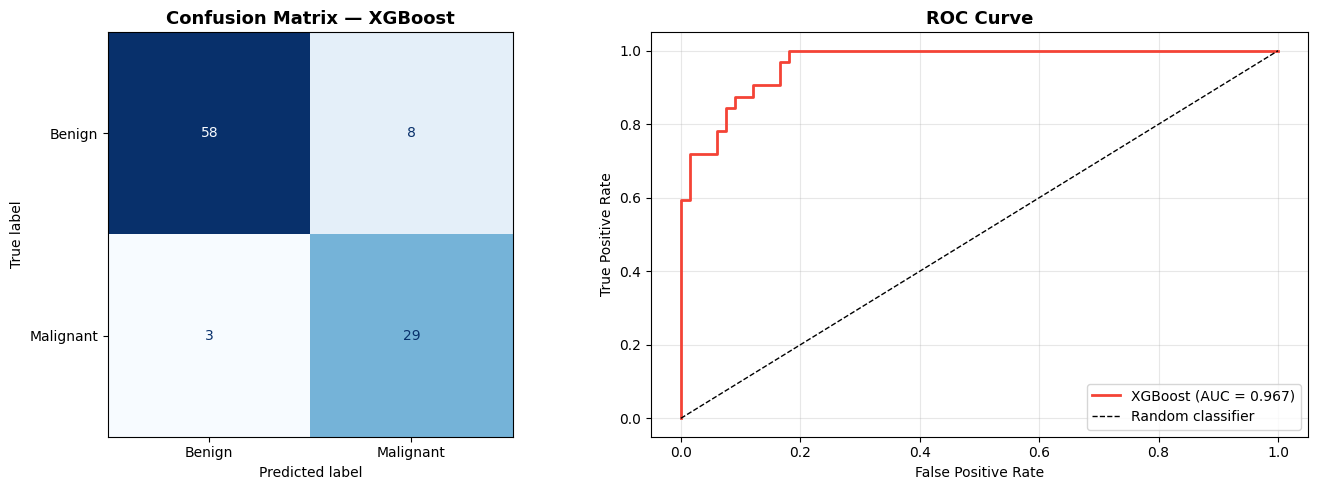


AUC Score: 0.9669


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Benign', 'Malignant'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — XGBoost', fontsize=13, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

axes[1].plot(fpr, tpr, color='#F44336', linewidth=2,
             label=f'XGBoost (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('tabular_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAUC Score: {auc_score:.4f}")

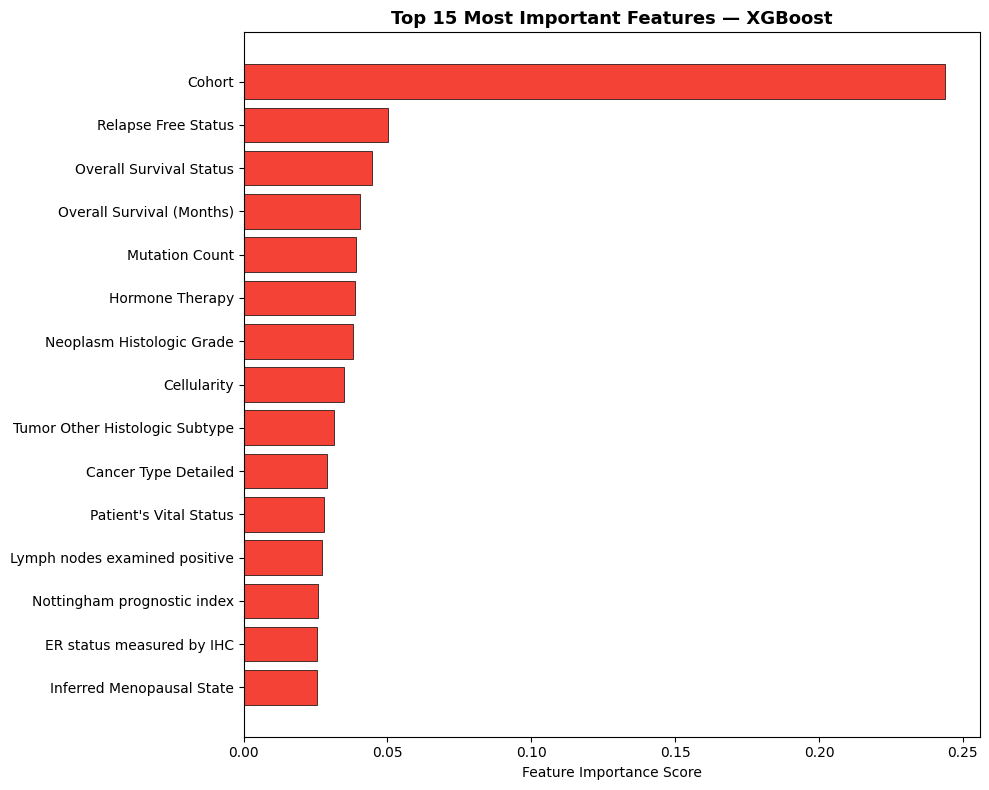

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

ax.barh(importance_df['feature'], importance_df['importance'],
        color='#F44336', edgecolor='black', linewidth=0.5)
ax.set_title('Top 15 Most Important Features — XGBoost',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance Score')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
cv_model = XGBClassifier(
    n_estimators=118,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

cv_scores = cross_val_score(cv_model, X, y, cv=5,
                             scoring='roc_auc', n_jobs=-1)

print(f"5-Fold Cross Validation AUC:")
print(f"Scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

5-Fold Cross Validation AUC:
Scores: [1.     1.     1.     0.98   0.7934]
Mean: 0.9547 (+/- 0.0810)


In [13]:
import json

tabular_results = {
    'model': 'XGBoost',
    'test_accuracy': float((y_pred == y_test).mean()),
    'auc': float(auc_score),
    'test_probs': y_probs.tolist(),
    'test_labels': y_test.tolist(),
    'test_preds': y_pred.tolist()
}

with open('tabular_results.json', 'w') as f:
    json.dump(tabular_results, f)

print(f"Test Accuracy: {tabular_results['test_accuracy']:.4f}")
print(f"AUC:           {tabular_results['auc']:.4f}")
print("Results saved to tabular_results.json — needed for Task 4 fusion model")

Test Accuracy: 0.8878
AUC:           0.9669
Results saved to tabular_results.json — needed for Task 4 fusion model


In [14]:
from google.colab import files
files.download('tabular_results.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>